# Training potential model from top-down

## Double-well top example
We consider ideal gas particles at a temperature kBT = 1 trapped inside a one-dimensional doublewell potential parametrized by
$$
    U(x) = k_B T * \left[ 2500(x-0.5)^6 - 10(x-0.5)^2\right]
$$


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import molpot as mpot
import torch
from torch_scatter import scatter_add
from molpot import alias

class DoubleWell(mpot.Potential):

    name = "DoubleWell"

    def __init__(self):
        super().__init__()

    def forward(self, inputs, outputs):

        d_ij = outputs['pairs'][alias.pair_dist]
        outputs['pairs']['double_well_energy'] = 2500.0 * (d_ij - 0.5) ** 6 - 10.0 * (d_ij - 0.55) ** 2
        outputs['atoms']['energy'] += scatter_add(outputs['pairs']['double_well_energy'], outputs['pairs']['pair_i'], dim=0)

        return inputs, outputs
    
class SingleWell(mpot.Potential):

    name = "SingleWell"

    def __init__(self, lambda_):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, inputs, outputs):

        d_ij = outputs['pairs'][alias.pair_dist]
        outputs['pairs']['single_well_energy'] = self.lambda_ * (d_ij - 0.5) ** 2

        return inputs, outputs

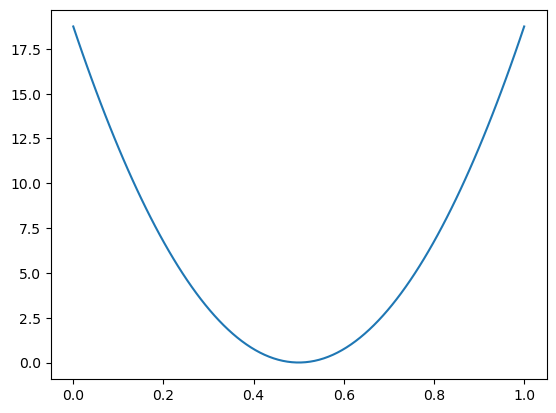

In [3]:
import matplotlib.pyplot as plt


U_prior = SingleWell(75.0)

inputs = mpot.Frame()
outputs = mpot.Frame()
outputs['pairs'][alias.pair_dist] = torch.linspace(0.0, 1.0, 100)
outputs['pairs']['pair_i'] = torch.arange(100, dtype=torch.long)
outputs['atoms']['energy'] = 0

inputs, outputs = U_prior(inputs, outputs)
plt.plot(outputs['pairs'][alias.pair_dist], outputs['pairs']['single_well_energy'])

(-1.0, 1.0)

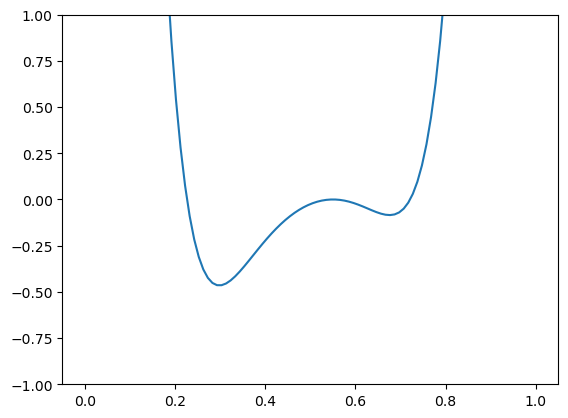

In [4]:
U = DoubleWell()

inputs, outputs = U(inputs, outputs)
plt.plot(outputs['pairs'][alias.pair_dist], outputs['pairs']['double_well_energy'])
plt.ylim(-1, 1)

In [5]:
class MonotonicInterpolate(mpot.Potential):
    """
    Piecewise cubic, monotonic interpolation via Steffens method [1].

    The interpolation curve is monotonic within each interval such that extrema
    can only occur at grid points. Guarantees continuous first derivatives
    of the spline. Is applicable to arbitrary data; not restricted to monotonic data.
    Contributed by Paul Fuchs.
    [1] Steffen, M., “A simple method for monotonic interpolation in one dimension.”,
    <i>Astronomy and Astrophysics</i>, vol. 239, pp. 443–450, 1990.

    Attributes:
        a, b, c, d: Piecewise coefficients for the cubic sections
        x: grid points

    Args:
        x : x-value of grid points -- must be strictly increasing
        y : y-value of grid points
        coefficients: Necessary for tree_unflatten

    Returns:
        A function that takes x values and returns spline values at these points
    """
    def __init__(self, x, y, coeffs=None):

        assert len(x) > 3, "Not enough input values for spline"
        assert len(x) == len(y), "x and y must have the same length"
        assert x.ndim == 1 and y.dim == 1, "Inputs must be 1D"

        if coeffs is None:

            h = torch.diff(x)
            k = torch.diff(y)
            s = k / h
            p = (s[0:-1] * h[1:] + s[1:] * h[0:-1]) / (h[0:-1] + h[1:])

            s0s1 = s[0:-1] * s[1:]
            a = torch.sign(s[0:-1])
            cond1 = torch.logical_or(
                torch.abs(p) > 2 * torch.abs(s[0:-1]),
                torch.abs(p) > 2 * torch.abs(s[1:]),
            )
            tmp = torch.where(
                cond1,
                2
                * a
                * torch.where(
                    torch.abs(s[0:1]) > torch.abs(s[1:]),
                    torch.abs(s[1:]),
                    torch.abs(s[0:-1]),
                ),
                p,
            )
            slopes = torch.where(s0s1 <= 0, 0.0, tmp)

            p0 = s[0] * (1 + h[0] / (h[0] + h[1])) - s[1] * (h[0] / (h[0] + h[1]))
            pn = s[-1] * (1 + h[-1] / (h[-1] + h[-2])) - s[-2] * (
                h[-1] / (h[-1] + h[-2])
            )

            tmp0 = torch.where(torch.abs(p0) > 2 * torch.abs(s[0]), 2 * s[0], p0)
            tmpn = torch.where(torch.abs(pn) > 2 * torch.abs(s[-1]), 2 * s[-1], pn)

            yp0 = torch.where(p0 * s[0] <= 0.0, 0.0, tmp0)
            ypn = torch.where(pn * s[-1] <= 0.0, 0.0, tmpn)
            slopes = torch.concatenate((torch.array([yp0]), slopes, torch.array([ypn])))

            # Build the coefficients and store properties
            a = (slopes[0:-1] + slopes[1:] - 2 * s) / torch.square(h)
            b = (3 * s - 2 * slopes[0:-1] - slopes[1:]) / h
            c = slopes
            d = y[0:-1]

            coefficients = (a, b, c, d)

        self.x = x
        self.y = y
        self.coefficients = coefficients

    def forward(self, inputs, outputs):
        """
        Evaluate spline at new data points.

        Args:
            x_new: Evaluation points

        Returns:
            Returns the interpolated values y_new corresponding to y_new.
        """
        x_new = inputs["xyz"]
        a, b, c, d = self.coefficients
        x_new_idx = torch.searchsorted(self.x, x_new, side="right") - 1  # Find the indexes of the reference

        # avoid out of bound indexing
        x_new_idx = torch.where(x_new_idx < 0, 0, x_new_idx)
        x_new_idx = torch.where(x_new_idx > len(self.x) - 2, len(self.x) - 2, x_new_idx)

        # Return the interpolated values
        a = a[x_new_idx]
        b = b[x_new_idx]
        c = c[x_new_idx]
        d = d[x_new_idx]

        x = self.x[x_new_idx]
        y_new = a * torch.power(x_new - x, 3) + b * torch.power(x_new - x, 2) + c * (x_new - x) + d

        outputs["monotonic_interpolation"] = y_new
        return inputs, outputs


## Reference Simulation

Next, we run a simulation using the analytic double well potential to generate a long trajectory for our
toy problem.

In [6]:
import molpot as mpot

# deinfe forcefield for MD simulation
ff = mpot.ForceField()
atomstyle = ff.def_atomstyle("particle")
atomstyle.def_atomtype("A", 1)
pairstyle = ff.def_pairstyle(DoubleWell)
pairstyle.def_pairtype('1-1', 1, 1)

# define particles
box = mpot.Box(torch.diag(torch.tensor([1.0, 1.0, 1.0])))

n_atoms = 10
frame = mpot.Frame()
xyz = box.lengths * torch.rand((n_atoms, 3))
xyz[:, 1:] = 0
xyz.requires_grad_(True)
frame['atoms']['xyz'] =  xyz
frame['atoms']['momentum'] = torch.zeros((n_atoms, 3))
frame['atoms']['force'] = torch.zeros((n_atoms, 3))
frame['atoms']['mass'] = torch.ones((n_atoms, 1))
frame['box']['cell'] = box.matrix
frame['box']['pbc'] = torch.tensor([True, True, True])

system = mpot.System()
system.frame = frame
system.forcefield = ff


In [7]:
engine = mpot.engine.MDEngine()
engine.fix.register(
    mpot.engine.fix.md.NaiveNeighborList(cutoff=1.0), engine.Stage.before_step
)
engine.fix.register(
    mpot.engine.fix.md.NVE(1.0), engine.Stage.half_step, engine.Stage.main_step
)
engine.fix.register(
    mpot.engine.fix.md.DumpXYZ(10), engine.Stage.before_step
)
engine.run(system, 100)


  0%|          | 0/100 [00:00<?, ?it/s]


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn